In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes
from scipy.stats import linregress
from matplotlib.patches import Rectangle

plot_path = '/home/u/u241308/figures/'

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#anomaly reference period
ref_min = 1985
ref_max = 2014

In [3]:
#regression time period
time_min = 1960
time_max = 1990

In [4]:
lead_min = 1 #to start in December, first lead year
lead_max = 13 #To end in November, first lead year

# SST

In [5]:
#select SPG area
lon_min_spg = -60
lon_max_spg = -10
lat_min_spg = 50
lat_max_spg = 66

In [6]:
#Hybrid ML
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/sst_ML_NA/anomaly/'
    file = 'sst_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as sst_ML:
        sst_ML = sst_ML.tos.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(sst_ML)

#concatenate along time dimension
sst_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
sst_ML['lon'] = np.where(sst_ML.lon > 180,sst_ML.lon-360,sst_ML.lon)
ind_sort = np.argsort(sst_ML.lon)
sst_ML = sst_ML[:,:,:,ind_sort.values]
#select lon/lat
lon_sel = (sst_ML.lon >= lon_min_spg) & (sst_ML.lon <= lon_max_spg)
lat_sel = (sst_ML.lat >= lat_min_spg) & (sst_ML.lat <= lat_max_spg)

sst_ML = sst_ML[:,:,lat_sel,lon_sel].mean(dim=('lon','lat'))

#change 'depth' dimension name to 'sfc', so the dimension name matches with z500 (only for ML, not for MPI)
sst_ML = sst_ML.rename({"depth": "sfc"})
#give different coordinates for each ensemble member in sfc:
sst_ML = sst_ML.assign_coords(sfc=np.arange(1, 17))

#homogenize time dimension, so each month's time corresponds to the first day, and first our
sst_ML['time'] = pd.to_datetime(sst_ML['time']) - pd.offsets.MonthBegin()
sst_ML['time'] = sst_ML['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [7]:
#Standard

# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/sst_benchmark/anomaly/'
    file = 'sst_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as sst_MPI:
        sst_MPI = sst_MPI.tos.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(sst_MPI)

#concatenate along time dimension
sst_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
sst_MPI['lon'] = np.where(sst_MPI.lon > 180,sst_MPI.lon-360,sst_MPI.lon)
ind_sort = np.argsort(sst_MPI.lon)
sst_MPI = sst_MPI[:,:,:,ind_sort.values]
#select lon/lat
lon_sel = (sst_MPI.lon >= lon_min_spg) & (sst_MPI.lon <= lon_max_spg)
lat_sel = (sst_MPI.lat >= lat_min_spg) & (sst_MPI.lat <= lat_max_spg)

sst_MPI = sst_MPI[:,:,lat_sel,lon_sel].mean(dim=('lon','lat'))
#change 'depth' dimension name to 'sfc', so the dimension name matches with z500 (only for ML, not for MPI)
sst_MPI = sst_MPI.rename({"depth": "sfc"})
#give different coordinates for each ensemble member in sfc:
sst_MPI = sst_MPI.assign_coords(sfc=np.arange(1, 17))

#homogenize time dimension, so each month's time corresponds to the first day, and first our
sst_MPI['time'] = sst_MPI['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [8]:
#ERA
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_sst_1940-2023_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
sst_era = xr.open_dataset(path+file).sst

#select period
sst_era = sst_era[(sst_era.time.dt.year>=time_min)&(sst_era.time.dt.year<=time_max)]

#new longitudes
sst_era['lon'] = np.where(sst_era.lon > 180,sst_era.lon-360,sst_era.lon)
ind_sort = np.argsort(sst_era.lon)
sst_era = sst_era[:,:,ind_sort.values]
#select lon/lat
lon_sel = (sst_era.lon >= lon_min_spg) & (sst_era.lon <= lon_max_spg)
lat_sel = (sst_era.lat >= lat_min_spg) & (sst_era.lat <= lat_max_spg)

sst_era = sst_era[:,lat_sel,lon_sel].mean(axis=(1,2))

#homogenize to MPI and ML
sst_era = sst_era.sel(time=slice(sst_MPI.time[0].time, sst_MPI.time[-1].time))

# Z500

In [9]:
#select North Atlantic area
lon_min_na = -70
lon_max_na = 30
lat_min_na = 20
lat_max_na = 80

In [10]:
# Hybrid ML
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/z500_ML_NA/anomaly/'
    file = 'z500_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as z500_ML:
        z500_ML = z500_ML.zg.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(z500_ML)

#concatenate along time dimension
z500_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
z500_ML['lon'] = np.where(z500_ML.lon > 180,z500_ML.lon-360,z500_ML.lon)
ind_sort = np.argsort(z500_ML.lon)
z500_ML = z500_ML[:,:,:,ind_sort.values]
#select lon/lat
lon_sel = (z500_ML.lon >= lon_min_na) & (z500_ML.lon <= lon_max_na)
lat_sel = (z500_ML.lat >= lat_min_na) & (z500_ML.lat <= lat_max_na)
    
z500_ML = z500_ML[:,:,lat_sel,lon_sel]

#change 'depth' dimension name to 'sfc', so the dimension name matches with TAS (only for ML, not for MPI)
z500_ML = z500_ML.rename({"plev_2": "sfc"})
#give different coordinates for each ensemble member in sfc:
z500_ML = z500_ML.assign_coords(sfc=np.arange(1, 17))

#homogenize time dimension, so each month's time corresponds to the first day, and first our
z500_ML['time'] = pd.to_datetime(z500_ML['time']) - pd.offsets.MonthBegin()
z500_ML['time'] = z500_ML['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [11]:
#Standard
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/z500_benchmark/anomaly/'
    file = 'z500_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as z500_MPI:
        z500_MPI = z500_MPI.zg.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(z500_MPI)

#concatenate along time dimension
z500_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
z500_MPI['lon'] = np.where(z500_MPI.lon > 180,z500_MPI.lon-360,z500_MPI.lon)
ind_sort = np.argsort(z500_MPI.lon)
z500_MPI = z500_MPI[:,:,:,ind_sort.values]
#select lon/lat
lon_sel = (z500_MPI.lon >= lon_min_na) & (z500_MPI.lon <= lon_max_na)
lat_sel = (z500_MPI.lat >= lat_min_na) & (z500_MPI.lat <= lat_max_na)

z500_MPI = z500_MPI[:,:,lat_sel,lon_sel]

#change 'depth' dimension name to 'sfc', so the dimension name matches with TAS (only for ML, not for MPI)
z500_MPI = z500_MPI.rename({"plev_2": "sfc"})
#give different coordinates for each ensemble member in sfc:
z500_MPI = z500_MPI.assign_coords(sfc=np.arange(1, 17))

#homogenize time dimension, so each month's time corresponds to the first day, and first our
z500_MPI['time'] = z500_MPI['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [12]:
#ERA
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_z500_1940-2023_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
z500_era = xr.open_dataset(path+file).z

#select period
z500_era = z500_era[(z500_era.time.dt.year>=time_min)&(z500_era.time.dt.year<=time_max)]

#new longitudes
z500_era['lon'] = np.where(z500_era.lon > 180,z500_era.lon-360,z500_era.lon)
ind_sort = np.argsort(z500_era.lon)
z500_era = z500_era[:,:,ind_sort.values]


lon_sel = (z500_era.lon >= lon_min_na) & (z500_era.lon <= lon_max_na)
lat_sel = (z500_era.lat >= lat_min_na) & (z500_era.lat <= lat_max_na)

z500_era = z500_era[:,lat_sel,lon_sel]

#homogenize to MPI and ML
z500_era = z500_era.sel(time=slice(z500_MPI.time[0].time, z500_MPI.time[-1].time))

# HFLS

In [13]:
# Hybrid ML
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/hfls_ML_NA/anomaly/'
    file = 'hfls_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as hfls_ML:
        hfls_ML = hfls_ML.__xarray_dataarray_variable__.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(hfls_ML)

#concatenate along time dimension
hfls_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
hfls_ML['lon'] = np.where(hfls_ML.lon > 180,hfls_ML.lon-360,hfls_ML.lon)
ind_sort = np.argsort(hfls_ML.lon)
hfls_ML = hfls_ML[:,:,:,ind_sort.values]

#select NA lon/lat
lon_sel = (hfls_ML.lon >= lon_min_na) & (hfls_ML.lon <= lon_max_na)
lat_sel = (hfls_ML.lat >= lat_min_na) & (hfls_ML.lat <= lat_max_na)

hfls_ML = hfls_ML[:,:,lat_sel,lon_sel]

#homogenize time dimension, so each month's time corresponds to the first day, and first our
hfls_ML['time'] = pd.to_datetime(hfls_ML['time']) - pd.offsets.MonthBegin()
hfls_ML['time'] = hfls_ML['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [14]:
# Standard
lead_min = 1 #to start in December, first lead year
lead_max = 13 #To end in November, first lead year

# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/hfls_benchmark/anomaly/'
    file = 'hfls_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as hfls_MPI:
        hfls_MPI = hfls_MPI.__xarray_dataarray_variable__.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(hfls_MPI)

#concatenate along time dimension
hfls_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
hfls_MPI['lon'] = np.where(hfls_MPI.lon > 180,hfls_MPI.lon-360,hfls_MPI.lon)
ind_sort = np.argsort(hfls_MPI.lon)
hfls_MPI = hfls_MPI[:,:,:,ind_sort.values]

#select NA lon/lat
lon_sel = (hfls_MPI.lon >= lon_min_na) & (hfls_MPI.lon <= lon_max_na)
lat_sel = (hfls_MPI.lat >= lat_min_na) & (hfls_MPI.lat <= lat_max_na)

hfls_MPI = hfls_MPI[:,:,lat_sel,lon_sel]

#homogenize time dimension, so each month's time corresponds to the first day, and first our
hfls_MPI['time'] = hfls_MPI['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [15]:
#ERA
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_hfls_1940-2024_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
hfls_era = xr.open_dataset(path+file).slhf

#select period
hfls_era = hfls_era[(hfls_era.time.dt.year>=time_min)&(hfls_era.time.dt.year<=time_max)]

#new longitudes
hfls_era['lon'] = np.where(hfls_era.lon > 180,hfls_era.lon-360,hfls_era.lon)
ind_sort = np.argsort(hfls_era.lon)
hfls_era = hfls_era[:,:,ind_sort.values]

#select NA lon/lat
lon_sel = (hfls_era.lon >= lon_min_na) & (hfls_era.lon <= lon_max_na)
lat_sel = (hfls_era.lat >= lat_min_na) & (hfls_era.lat <= lat_max_na)

hfls_era = hfls_era[:,lat_sel,lon_sel]

#homogenize to MPI and ML
hfls_era['time'] = hfls_era['time'].dt.floor('D')
hfls_era = hfls_era.sel(time=slice(hfls_MPI.time[0].time, hfls_MPI.time[-1].time))

# HFSS

In [16]:
# Hybrid ML
lead_min = 1 #to start in December, first lead year
lead_max = 13 #To end in November, first lead year

# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/hfss_ML_NA/anomaly/'
    file = 'hfss_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as hfss_ML:
        hfss_ML = hfss_ML.__xarray_dataarray_variable__.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(hfss_ML)

#concatenate along time dimension
hfss_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
hfss_ML['lon'] = np.where(hfss_ML.lon > 180,hfss_ML.lon-360,hfss_ML.lon)
ind_sort = np.argsort(hfss_ML.lon)
hfss_ML = hfss_ML[:,:,:,ind_sort.values]

#select NA lon/lat
lon_sel = (hfss_ML.lon >= lon_min_na) & (hfss_ML.lon <= lon_max_na)
lat_sel = (hfss_ML.lat >= lat_min_na) & (hfss_ML.lat <= lat_max_na)

hfss_ML = hfss_ML[:,:,lat_sel,lon_sel]

#homogenize time dimension, so each month's time corresponds to the first day, and first our
hfss_ML['time'] = pd.to_datetime(hfss_ML['time']) - pd.offsets.MonthBegin()
hfss_ML['time'] = hfss_ML['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [17]:
# Standard
lead_min = 1 #to start in December, first lead year
lead_max = 13 #To end in November, first lead year

# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/hfss_benchmark/anomaly/'
    file = 'hfss_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as hfss_MPI:
        hfss_MPI = hfss_MPI.__xarray_dataarray_variable__.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(hfss_MPI)

#concatenate along time dimension
hfss_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
hfss_MPI['lon'] = np.where(hfss_MPI.lon > 180,hfss_MPI.lon-360,hfss_MPI.lon)
ind_sort = np.argsort(hfss_MPI.lon)
hfss_MPI = hfss_MPI[:,:,:,ind_sort.values]

#select NA lon/lat
lon_sel = (hfss_MPI.lon >= lon_min_na) & (hfss_MPI.lon <= lon_max_na)
lat_sel = (hfss_MPI.lat >= lat_min_na) & (hfss_MPI.lat <= lat_max_na)

hfss_MPI = hfss_MPI[:,:,lat_sel,lon_sel]

#homogenize time dimension, so each month's time corresponds to the first day, and first our
hfss_MPI['time'] = hfss_MPI['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [18]:
#ERA
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_hfss_1940-2024_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
hfss_era = xr.open_dataset(path+file).sshf

#select period
hfss_era = hfss_era[(hfss_era.time.dt.year>=time_min)&(hfss_era.time.dt.year<=time_max)]

#new longitudes
hfss_era['lon'] = np.where(hfss_era.lon > 180,hfss_era.lon-360,hfss_era.lon)
ind_sort = np.argsort(hfss_era.lon)
hfss_era = hfss_era[:,:,ind_sort.values]

#select NA lon/lat
lon_sel = (hfss_era.lon >= lon_min_na) & (hfss_era.lon <= lon_max_na)
lat_sel = (hfss_era.lat >= lat_min_na) & (hfss_era.lat <= lat_max_na)

hfss_era = hfss_era[:,lat_sel,lon_sel]

#homogenize to MPI and ML
hfss_era['time'] = hfss_era['time'].dt.floor('D')
hfss_era = hfss_era.sel(time=slice(hfss_MPI.time[0].time, hfss_MPI.time[-1].time))

# Total flux

In [19]:
# MPI
totalflux_MPI = hfls_MPI + hfss_MPI

# ML
totalflux_ML = hfls_ML + hfss_ML

# ERA
totalflux_era = hfls_era + hfss_era

#give different coordinates for each ensemble member in sfc:
totalflux_MPI = totalflux_MPI.assign_coords(sfc=np.arange(1, 17))
totalflux_ML = totalflux_ML.assign_coords(sfc=np.arange(1, 17))

# Seasonal regression

In [20]:
def compute_seasonal_means(da):
    time = da['time'].to_index()

    season_year = time.year + (time.month == 12)
    season = da['time'].dt.season.values

    season_id = [f"{y}-{s}" for y, s in zip(season_year, season)]

    da = da.assign_coords(
        season=('time', season),
        season_year=('time', season_year),
        season_id=('time', season_id)
    )

    grouped = da.groupby('season_id').mean('time')

    season_ts = {}
    for sid in grouped['season_id'].values:
        year, s = sid.split('-')
        year = int(year)
        if s not in season_ts:
            season_ts[s] = []
        da_season = grouped.sel(season_id=sid).expand_dims({'season_year': [year]})
        season_ts[s].append(da_season)

    for season in season_ts:
        season_ts[season] = xr.concat(season_ts[season], dim='season_year')

    return season_ts

In [21]:
# Compute seasonal mean
sst_era_seasonal = compute_seasonal_means(sst_era)
z500_era_seasonal = compute_seasonal_means(z500_era)
totalflux_era_seasonal = compute_seasonal_means(totalflux_era)

sst_MPI_seasonal = compute_seasonal_means(sst_MPI)
z500_MPI_seasonal = compute_seasonal_means(z500_MPI)
totalflux_MPI_seasonal = compute_seasonal_means(totalflux_MPI)

sst_ML_seasonal = compute_seasonal_means(sst_ML)
z500_ML_seasonal = compute_seasonal_means(z500_ML)
totalflux_ML_seasonal = compute_seasonal_means(totalflux_ML)

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spa

# Feedback - coupling strength

In [23]:
def compute_feedback_map_ens(sst, flux):
    sst, flux = xr.align(sst, flux)  # make sure dims match
    sst_flat = sst.stack(sample=('season_year','sfc'))
    flux_flat = flux.stack(sample=('season_year','sfc')).transpose('sample','lat','lon')

    nlat, nlon = flux.lat.size, flux.lon.size
    slope_map = np.full((nlat, nlon), np.nan)
    pval_map  = np.full((nlat, nlon), np.nan)
    
    for i in range(nlat):
        for j in range(nlon):
            x = sst_flat.values        # (480,)
            y = flux_flat.values[:, i, j]  # (480,)
            mask = ~np.isnan(x) & ~np.isnan(y)
            if np.sum(mask) > 1:
                slope, _, _, p_value, _ = linregress(x[mask], y[mask])
                slope_map[i, j] = slope
                pval_map[i, j]  = p_value
    # Return as xarray DataArrays
    slope_da = xr.DataArray(slope_map, coords={'lat': flux.lat, 'lon': flux.lon}, dims=['lat','lon'])
    pval_da  = xr.DataArray(pval_map,  coords={'lat': flux.lat, 'lon': flux.lon}, dims=['lat','lon'])
    
    return slope_da, pval_da

In [24]:
def compute_feedback_map(sst, flux):
    sst, flux = xr.align(sst, flux)  # make sure dims match

    nlat, nlon = flux.lat.size, flux.lon.size
    slope_map = np.full((nlat, nlon), np.nan)
    pval_map  = np.full((nlat, nlon), np.nan)

    for i in range(nlat):
        for j in range(nlon):
            x = sst.values        # (480,)
            y = flux.values[:, i, j]  # (480,)
            mask = ~np.isnan(x) & ~np.isnan(y)
            if np.sum(mask) > 1:
                slope, _, _, p_value, _ = linregress(x[mask], y[mask])
                slope_map[i, j] = slope
                pval_map[i, j]  = p_value
    # Return as xarray DataArrays
    slope_da = xr.DataArray(slope_map, coords={'lat': flux.lat, 'lon': flux.lon}, dims=['lat','lon'])
    pval_da  = xr.DataArray(pval_map,  coords={'lat': flux.lat, 'lon': flux.lon}, dims=['lat','lon'])
    
    return slope_da, pval_da

In [25]:
#Compute seasonal regression sst-Fluxes
season_list = ['DJF','MAM','JJA','SON']

sst_totalflux_era_seasonal_feedback = {}
sst_totalflux_MPI_seasonal_feedback = {}
sst_totalflux_ML_seasonal_feedback = {}

sst_totalflux_era_seasonal_feedback_pval = {}
sst_totalflux_MPI_seasonal_feedback_pval = {}
sst_totalflux_ML_seasonal_feedback_pval = {}

for seas in season_list:
    #era
    sst_totalflux_era_seasonal_feedback[seas],sst_totalflux_era_seasonal_feedback_pval[seas] = compute_feedback_map(sst_era_seasonal[seas],totalflux_era_seasonal[seas])
    #MPI
    sst_totalflux_MPI_seasonal_feedback[seas],sst_totalflux_MPI_seasonal_feedback_pval[seas] = compute_feedback_map_ens(sst_MPI_seasonal[seas],totalflux_MPI_seasonal[seas])
    #ML
    sst_totalflux_ML_seasonal_feedback[seas],sst_totalflux_ML_seasonal_feedback_pval[seas] = compute_feedback_map_ens(sst_ML_seasonal[seas],totalflux_ML_seasonal[seas])

In [26]:
#Compute seasonal regression sst-z500
season_list = ['DJF','MAM','JJA','SON']

sst_z500_era_seasonal_feedback = {}
sst_z500_MPI_seasonal_feedback = {}
sst_z500_ML_seasonal_feedback = {}

sst_z500_era_seasonal_feedback_pval = {}
sst_z500_MPI_seasonal_feedback_pval = {}
sst_z500_ML_seasonal_feedback_pval = {}

for seas in season_list:
    #era
    sst_z500_era_seasonal_feedback[seas],sst_z500_era_seasonal_feedback_pval[seas] = compute_feedback_map(sst_era_seasonal[seas],z500_era_seasonal[seas])
    #MPI
    sst_z500_MPI_seasonal_feedback[seas],sst_z500_MPI_seasonal_feedback_pval[seas] = compute_feedback_map_ens(sst_MPI_seasonal[seas],z500_MPI_seasonal[seas])
     #ML
    sst_z500_ML_seasonal_feedback[seas],sst_z500_ML_seasonal_feedback_pval[seas] = compute_feedback_map_ens(sst_ML_seasonal[seas],z500_ML_seasonal[seas])

In [27]:
#create a discrete colormaps
import matplotlib as mpl

#Z500 map
cmap = plt.cm.RdBu_r  # define the colormap
cmaplist = [cmap(i) for i in range(cmap.N)]
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, cmap.N)
bounds = np.linspace(-100, 100, 11)
norm_z500 = mpl.colors.BoundaryNorm(bounds, cmap.N)
bounds = np.linspace(-100, 100, 11)
norm_z500_era = mpl.colors.BoundaryNorm(bounds, cmap.N)

#THF map
bounds = np.linspace(-50, 50, 11)
norm_THF = mpl.colors.BoundaryNorm(bounds, cmap.N)
bounds = np.linspace(-50, 50, 11)
norm_THF_era = mpl.colors.BoundaryNorm(bounds, cmap.N)

In [28]:
#mark relevant THF area
lon_min_thf = -53
lon_max_thf = -43
lat_min_thf = 53
lat_max_thf = 60

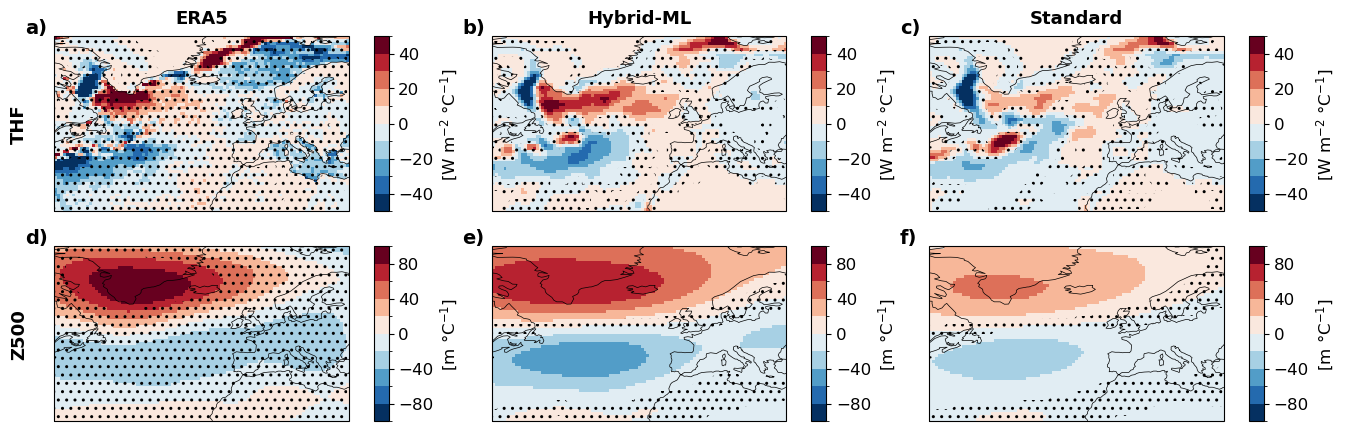

In [29]:
seas = 'DJF'
hatching = 1

#Plot
row = 2
column = 3

fig = plt.figure(figsize=(16,5))#(22,15))
plt.rcParams.update({'font.size': 12})
#plt.suptitle('SST-TAS correlation')

# =========================== ERA5 ============================
#THF
plot_data = sst_totalflux_era_seasonal_feedback[seas]
pvals = sst_totalflux_era_seasonal_feedback_pval[seas]
ax1 = plt.subplot(row,column,0*column+1, projection=ccrs.PlateCarree())
# ---- CORRELATION MAP ----
pcm = plt.pcolormesh(
    plot_data.lon,
    plot_data.lat,
    plot_data,
    cmap=cmap,
    norm=norm_THF_era,
    transform=ccrs.PlateCarree()
)
if hatching == 1:
    # ---- HATCHING FOR NON-SIGNIFICANT GRIDS ----
    mask = (pvals > 0.05).astype(int)   # numeric mask required
    ax1.contourf(
        plot_data.lon,
        plot_data.lat,
        mask,
        levels=[0.5, 1.5],          # everything >0.5 is considered non-significant
        colors='none',               # no color fill
        hatches=['..'],             # hatching style
        transform=ccrs.PlateCarree(),
        zorder=10
    )
ax1.coastlines(resolution='110m',lw=0.5,color='k'); ax1.set_facecolor('w')
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
cb = plt.colorbar(pcm,cax=cax)
cb.set_label(r'[W m$^{-2}$ °C$^{-1}$]') 
ax1.text(-0.15, 0.5, 'THF', transform=ax1.transAxes,
            va='center', rotation='vertical', fontsize=13, fontweight='bold')
ax1.text(0.5, 1.05, 'ERA5', transform=ax1.transAxes,
            ha='center', va='bottom', fontsize=13, fontweight='bold')

#Z500
plot_data = sst_z500_era_seasonal_feedback[seas]
pvals = sst_z500_era_seasonal_feedback_pval[seas]
ax2 = plt.subplot(row,column,1*column+1, projection=ccrs.PlateCarree())
# ---- CORRELATION MAP ----
pcm = plt.pcolormesh(
    plot_data.lon,
    plot_data.lat,
    plot_data,
    cmap=cmap,
    norm=norm_z500_era,
    transform=ccrs.PlateCarree()
)
if hatching == 1:
    # ---- HATCHING FOR NON-SIGNIFICANT GRIDS ----
    mask = (pvals > 0.05).astype(int)   # numeric mask required
    ax2.contourf(
        plot_data.lon,
        plot_data.lat,
        mask,
        levels=[0.5, 1.5],          # everything >0.5 is considered non-significant
        colors='none',               # no color fill
        hatches=['..'],             # hatching style
        transform=ccrs.PlateCarree(),
        zorder=10
    )
ax2.coastlines(resolution='110m',lw=0.5,color='k'); ax2.set_facecolor('w')
divider = make_axes_locatable(ax2)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
cb = plt.colorbar(pcm,cax=cax)
cb.set_label(r'[m °C$^{-1}$]') 
ax2.text(-0.15, 0.5, 'Z500', transform=ax2.transAxes,
            va='center', rotation='vertical', fontsize=13, fontweight='bold')

# =========================== ML ============================
#THF
plot_data = sst_totalflux_ML_seasonal_feedback[seas]
pvals = sst_totalflux_ML_seasonal_feedback_pval[seas]
ax3 = plt.subplot(row,column,0*column+2, projection=ccrs.PlateCarree())
# ---- CORRELATION MAP ----
pcm = plt.pcolormesh(
    plot_data.lon,
    plot_data.lat,
    plot_data,
    cmap=cmap,
    norm=norm_THF,
    transform=ccrs.PlateCarree()
)
if hatching == 1:
    # ---- HATCHING FOR NON-SIGNIFICANT GRIDS ----
    mask = (pvals > 0.05).astype(int)   # numeric mask required
    ax3.contourf(
        plot_data.lon,
        plot_data.lat,
        mask,
        levels=[0.5, 1.5],          # everything >0.5 is considered non-significant
        colors='none',               # no color fill
        hatches=['..'],             # hatching style
        transform=ccrs.PlateCarree(),
        zorder=10
    )
ax3.coastlines(resolution='110m',lw=0.5,color='k'); ax3.set_facecolor('w')
divider = make_axes_locatable(ax3)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
cb = plt.colorbar(pcm,cax=cax)
cb.set_label(r'[W m$^{-2}$ °C$^{-1}$]') 
ax3.text(0.5, 1.05, 'Hybrid-ML', transform=ax3.transAxes,
            ha='center', va='bottom', fontsize=13, fontweight='bold')

#Z500
plot_data = sst_z500_ML_seasonal_feedback[seas]
pvals = sst_z500_ML_seasonal_feedback_pval[seas]
ax4 = plt.subplot(row,column,1*column+2, projection=ccrs.PlateCarree())
# ---- CORRELATION MAP ----
pcm = plt.pcolormesh(
    plot_data.lon,
    plot_data.lat,
    plot_data,
    cmap=cmap,
    norm=norm_z500,
    transform=ccrs.PlateCarree()
)
if hatching == 1:
    # ---- HATCHING FOR NON-SIGNIFICANT GRIDS ----
    mask = (pvals > 0.05).astype(int)   # numeric mask required
    ax4.contourf(
        plot_data.lon,
        plot_data.lat,
        mask,
        levels=[0.5, 1.5],          # everything >0.5 is considered non-significant
        colors='none',               # no color fill
        hatches=['..'],             # hatching style
        transform=ccrs.PlateCarree(),
        zorder=10
    )
ax4.coastlines(resolution='110m',lw=0.5,color='k'); ax4.set_facecolor('w')
divider = make_axes_locatable(ax4)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
cb = plt.colorbar(pcm,cax=cax)
cb.set_label(r'[m °C$^{-1}$]') 

# =========================== MPI ============================
#THF
plot_data = sst_totalflux_MPI_seasonal_feedback[seas]
pvals = sst_totalflux_MPI_seasonal_feedback_pval[seas]
ax5 = plt.subplot(row,column,0*column+3, projection=ccrs.PlateCarree())
# ---- CORRELATION MAP ----
pcm = plt.pcolormesh(
    plot_data.lon,
    plot_data.lat,
    plot_data,
    cmap=cmap,
    norm=norm_THF,
    transform=ccrs.PlateCarree()
)
if hatching == 1:
    # ---- HATCHING FOR NON-SIGNIFICANT GRIDS ----
    mask = (pvals > 0.05).astype(int)   # numeric mask required
    ax5.contourf(
        plot_data.lon,
        plot_data.lat,
        mask,
        levels=[0.5, 1.5],          # everything >0.5 is considered non-significant
        colors='none',               # no color fill
        hatches=['..'],             # hatching style
        transform=ccrs.PlateCarree(),
        zorder=10
    )
ax5.coastlines(resolution='110m',lw=0.5,color='k'); ax5.set_facecolor('w')
divider = make_axes_locatable(ax5)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
cb = plt.colorbar(pcm,cax=cax)
cb.set_label(r'[W m$^{-2}$ °C$^{-1}$]') 
ax5.text(0.5, 1.05, 'Standard', transform=ax5.transAxes,
            ha='center', va='bottom', fontsize=13, fontweight='bold')

#Z500
plot_data = sst_z500_MPI_seasonal_feedback[seas]
pvals = sst_z500_MPI_seasonal_feedback_pval[seas]
ax6 = plt.subplot(row,column,1*column+3, projection=ccrs.PlateCarree())
# ---- CORRELATION MAP ----
pcm = plt.pcolormesh(
    plot_data.lon,
    plot_data.lat,
    plot_data,
    cmap=cmap,
    norm=norm_z500,
    transform=ccrs.PlateCarree()
)
if hatching == 1:
    # ---- HATCHING FOR NON-SIGNIFICANT GRIDS ----
    mask = (pvals > 0.05).astype(int)   # numeric mask required
    ax6.contourf(
        plot_data.lon,
        plot_data.lat,
        mask,
        levels=[0.5, 1.5],          # everything >0.5 is considered non-significant
        colors='none',               # no color fill
        hatches=['..'],             # hatching style
        transform=ccrs.PlateCarree(),
        zorder=10
    )
ax6.coastlines(resolution='110m',lw=0.5,color='k'); ax6.set_facecolor('w')
divider = make_axes_locatable(ax6)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
cb = plt.colorbar(pcm,cax=cax)
cb.set_label(r'[m °C$^{-1}$]') 

# ================= Text =====================

x_pos = -0.1
y_pos = 1.1
ax1.text(
    x_pos, y_pos, 'a)',   # position (x,y)
    transform=ax1.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

ax2.text(
    x_pos, y_pos, 'd)',   # position (x,y)
    transform=ax2.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

ax3.text(
    x_pos, y_pos, 'b)',   # position (x,y)
    transform=ax3.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)
ax4.text(
    x_pos, y_pos, 'e)',   # position (x,y)
    transform=ax4.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

ax5.text(
    x_pos, y_pos, 'c)',   # position (x,y)
    transform=ax5.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

ax6.text(
    x_pos, y_pos, 'f)',   # position (x,y)
    transform=ax6.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)
plt.savefig(plot_path+'sst_heatfluxes_z500_'+seas+'_regression_also_era_period_%i-%i_anomaly_ref_%i-%i'%(time_min,time_max,ref_min,ref_max),bbox_inches="tight",dpi=100) 